In [1]:
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import umap.umap_ as umap

from sklearn import preprocessing
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from collections import defaultdict
from pathlib import Path

/storage/vast-gfz-hpc-01/home/wuhlmann/miniforge3/envs/lamah-ce_lstm/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Create strata.

In [2]:
# Remove NA & non-numeric columns and normalize with z-score for PCA.

scaler = preprocessing.StandardScaler()

# Load attributes and hydrologic indices.
attributes_shape_path = Path("/home/wuhlmann/BA/data/raw_data/2_LamaH-CE_daily/B_basins_intermediate_all/3_shapefiles/Basins_B.shp")
hydro_indices_path = Path("/home/wuhlmann/BA/data/raw_data/2_LamaH-CE_daily/D_gauges/1_attributes/Hydro_indices_1981_2017.csv")

basin_stca_gdf = gpd.read_file(attributes_shape_path)
basin_stca_gdf.set_index("ID", inplace=True)

# Drop Na and non-numeric columns, to prep for clustering.
no_na_attributes = basin_stca_gdf.dropna().sort_index()
numeric_attributes = no_na_attributes.select_dtypes(include=["number"])
scaled_attributes = pd.DataFrame(
    scaler.fit_transform(numeric_attributes.values),
    columns=numeric_attributes.columns,
    index=numeric_attributes.index
)

# hy id are used to validate the clusters, which are based on the catchment attributes.
hydro_indices = pd.read_table(hydro_indices_path, header=0, sep=";")
hydro_indices.set_index("ID", inplace=True)

no_na_hy_id = hydro_indices.dropna()
numeric_hy_id = no_na_hy_id.select_dtypes(include=["number"])
scaled_hy_id = pd.DataFrame(
    scaler.fit_transform(numeric_hy_id.values),
    columns=numeric_hy_id.columns,
    index=numeric_hy_id.index
)

# Remove basins for which no hy_id exists. 
common_ids = scaled_attributes.index.intersection(scaled_hy_id.index)
#scaled_attributes = scaled_attributes.loc[common_ids]
#scaled_hy_id = scaled_hy_id.loc[common_ids]

#### Determine static catchment attributes to be used.

In [3]:
scaled_attributes.columns

Index(['area_calc', 'elev_mean', 'elev_med', 'elev_std', 'elev_ran',
       'slope_mean', 'mvert_dist', 'mvert_ang', 'elon_ratio', 'strm_dens',
       'p_mean', 'et0_mean', 'eta_mean', 'arid_1', 'arid_2', 'p_season',
       'frac_snow', 'hi_prec_fr', 'hi_prec_du', 'lo_prec_fr', 'lo_prec_du',
       'lc_dom', 'agr_fra', 'bare_fra', 'forest_fra', 'glac_fra', 'lake_fra',
       'urban_fra', 'lai_max', 'lai_diff', 'ndvi_max', 'ndvi_min', 'gvf_max',
       'gvf_diff', 'bedrk_dep', 'root_dep', 'soil_poros', 'soil_condu',
       'soil_tawc', 'sand_fra', 'silt_fra', 'clay_fra', 'grav_fra', 'oc_fra',
       'gc_ig_fra', 'gc_mt_fra', 'gc_pa_fra', 'gc_pb_fra', 'gc_pi_fra',
       'gc_py_fra', 'gc_sc_fra', 'gc_sm_fra', 'gc_ss_fra', 'gc_su_fra',
       'gc_va_fra', 'gc_vb_fra', 'gc_wb_fra', 'geol_perme', 'geol_poros',
       'NEXTDOWNID'],
      dtype='object')

/tmp/ipykernel_1735667/3765335919.py:60: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


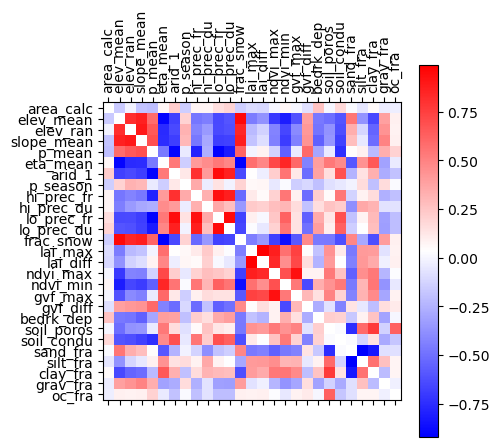

In [4]:
potential_attributes = [
    #geomorph - unargueable
    "area_calc",
    "elev_mean",
    "elev_ran",
    "slope_mean",

    #precipitation
    "p_mean", # influx
    "eta_mean", # outflux
    "arid_1",
    "p_season",
    "hi_prec_fr",
    "hi_prec_du",
    "lo_prec_fr",
    "lo_prec_du",
    "frac_snow",

    #land cover - the first to be cut, since no literature had them.
    #"agr_fra",
    #"bare_fra",
    #"forest_fra", # maybe just keep this one
    #"glac_fra",
    #"lake_fra",
    #"urban_fra",

    #vegetation - cut maybe some, to reduce correlation, probably choose lai or ndvi.
    "lai_max",
    "lai_diff",
    "ndvi_max",
    "ndvi_min",
    "gvf_max",
    "gvf_diff",

    #soil
    "bedrk_dep",
    "soil_poros",
    "soil_condu",
    "sand_fra",
    "silt_fra",
    "clay_fra",
    "grav_fra",
    "oc_fra"
]

len(potential_attributes)

scaled_attributes = scaled_attributes[potential_attributes]

corr_mat = scaled_attributes.corr()

for i in range(len(corr_mat)): 

    corr_mat.iloc[i,i] = np.nan

plt.matshow(corr_mat, cmap="bwr")
plt.yticks(ticks=range(len(corr_mat)), labels=corr_mat.columns)
plt.xticks(ticks=range(len(corr_mat)), labels=corr_mat.columns, rotation=90)
plt.colorbar()
plt.tight_layout()

In [5]:
len(scaled_attributes.columns)

27

In [6]:
corr_mat[corr_mat.max() > 0.9].index

Index(['elev_mean', 'arid_1', 'hi_prec_fr', 'lo_prec_fr', 'lo_prec_du',
       'frac_snow', 'lai_max', 'lai_diff', 'ndvi_max', 'gvf_max'],
      dtype='object')

#### Clustering.

In [7]:
# PCA since there are a lot of attributes, which are sometimes correlated. 
pca = PCA(n_components=0.9, svd_solver="full")
pca_attributes = pca.fit_transform(scaled_attributes)

/storage/vast-gfz-hpc-01/home/wuhlmann/miniforge3/envs/lamah-ce_lstm/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


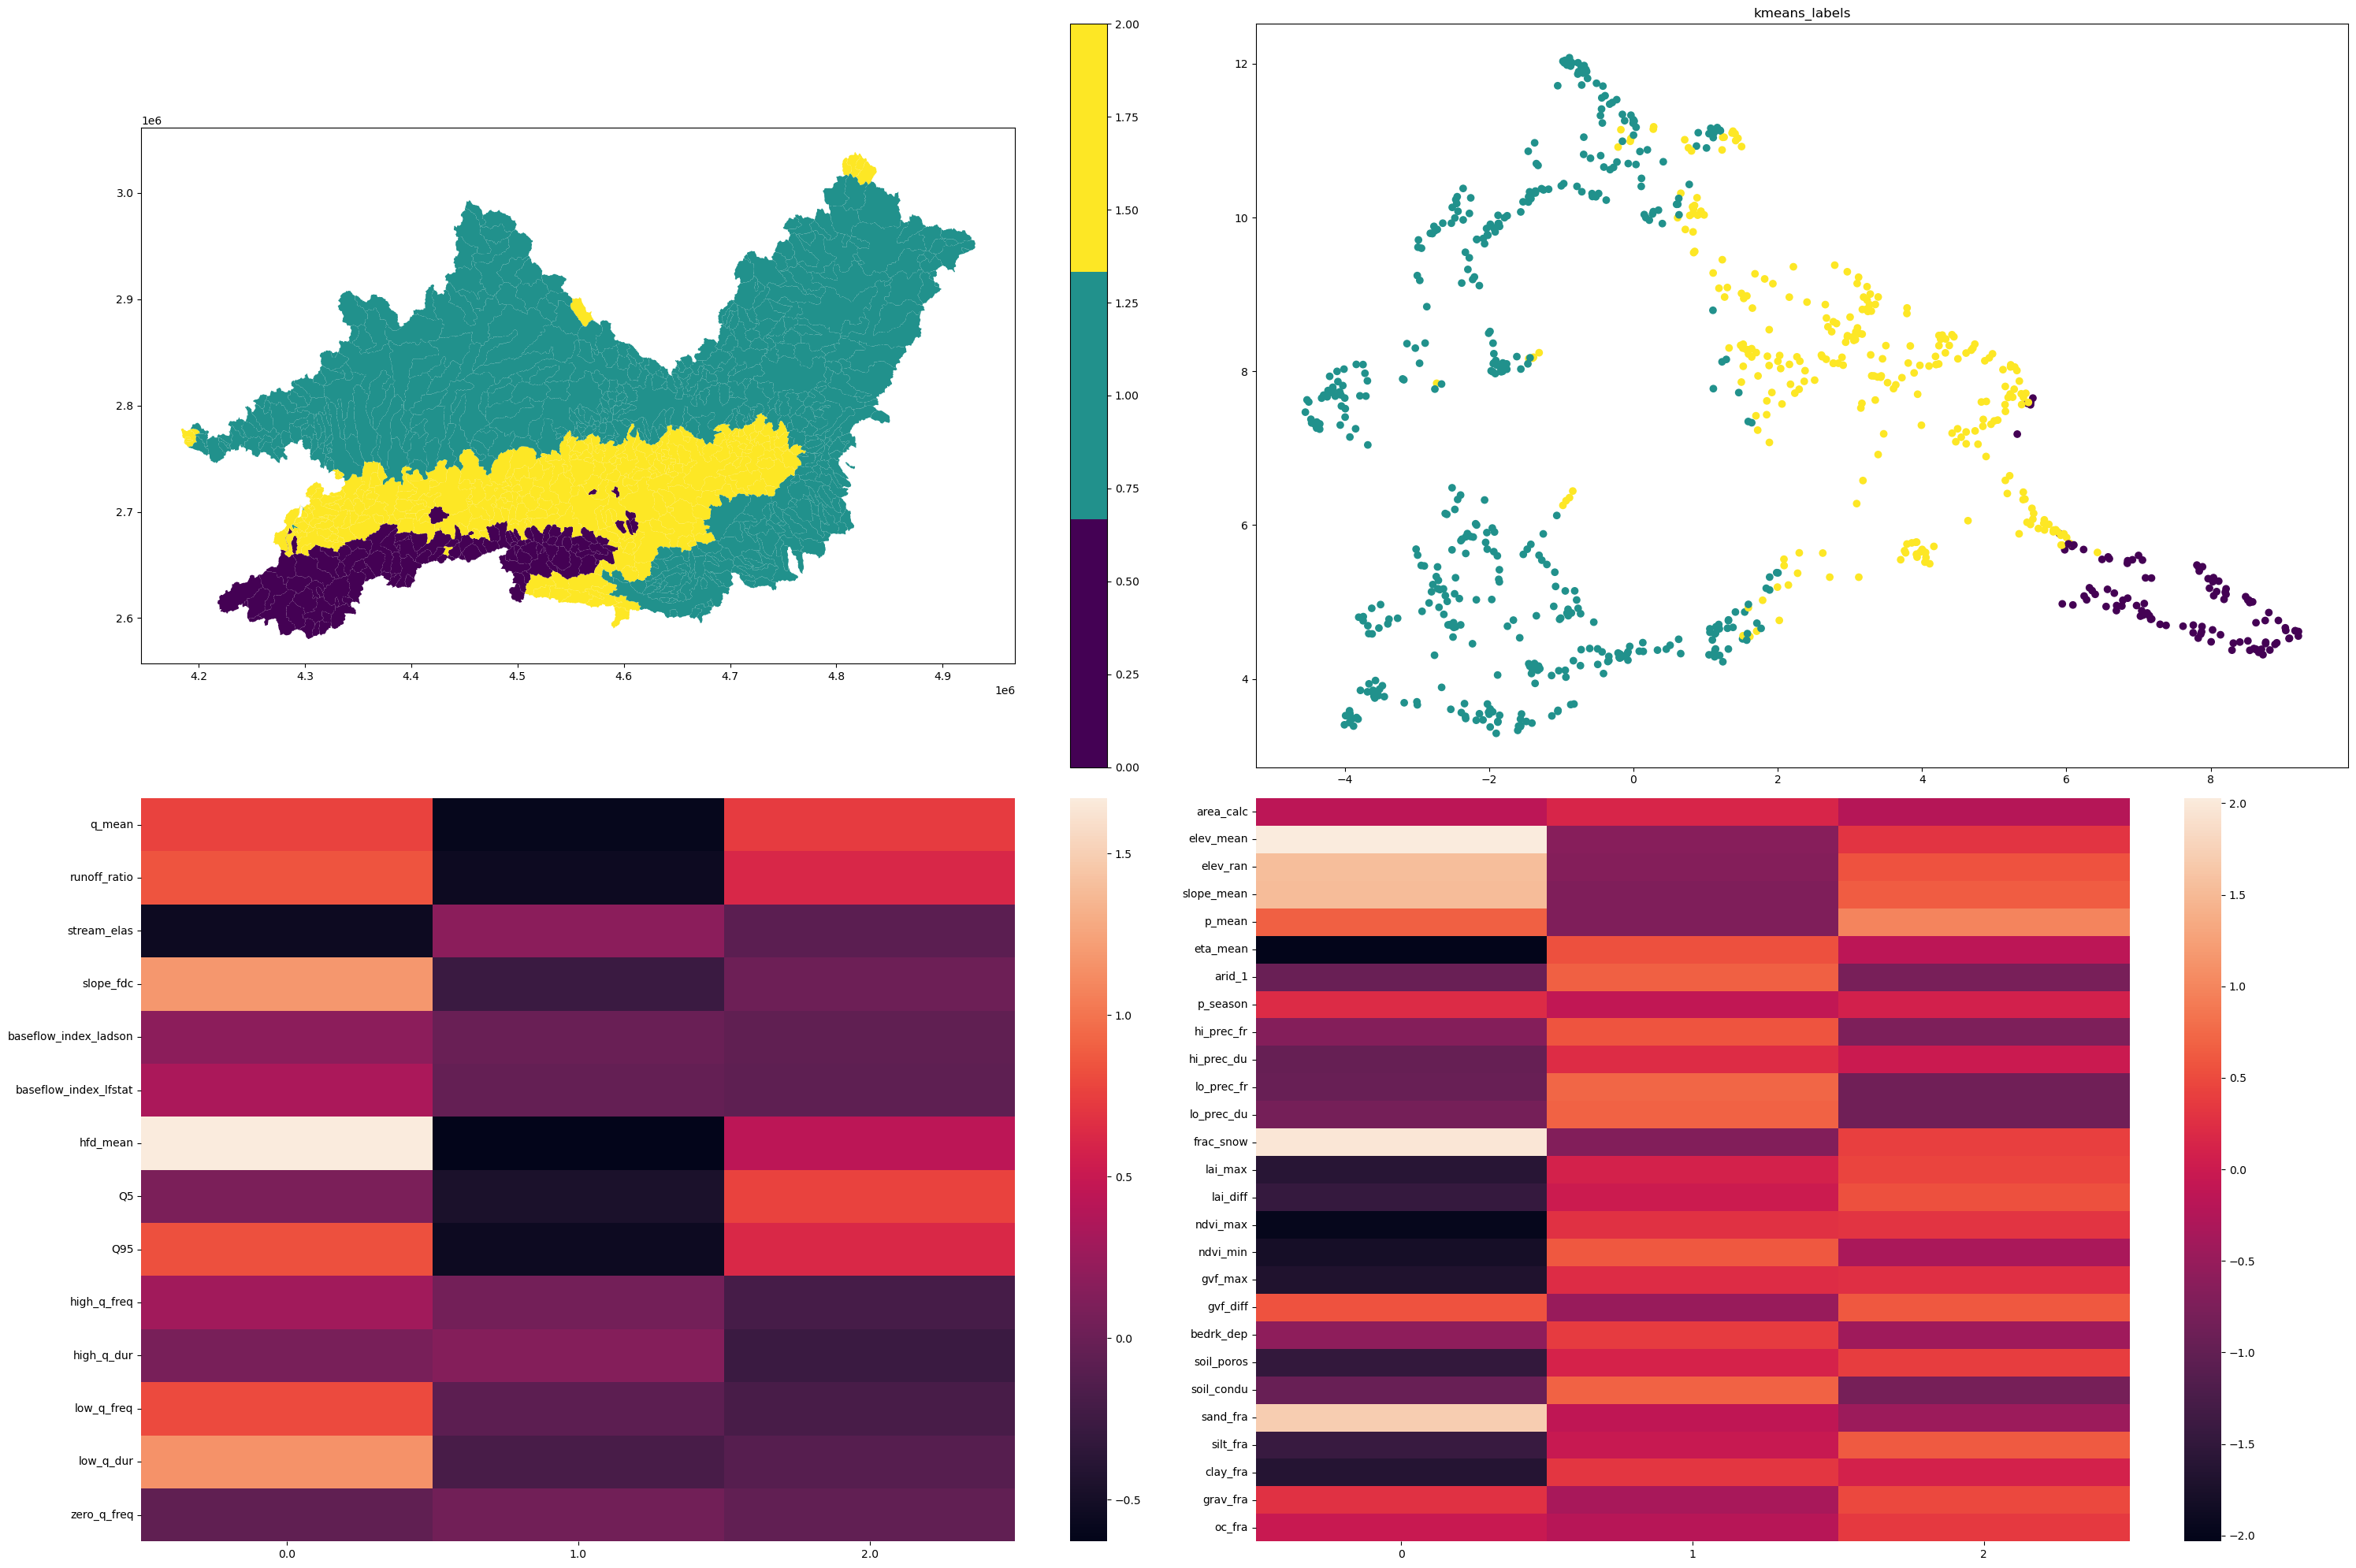

In [8]:
n_clusters = 3
seed =  12 

# KMEANS
kmeans = KMeans(n_clusters=n_clusters, random_state=seed)

# Fit on normal basins. 
kmeans_labels = pd.Series(kmeans.fit_predict(pca_attributes), scaled_attributes.index)

# PLOT
plot_gdf = no_na_attributes.copy()
plot_gdf["kmeans_labels"] = kmeans_labels

# Assign one fix color for each cluster
cmap = mpl.colormaps["viridis"].resampled(n_clusters)
vmin = plot_gdf["kmeans_labels"].min()
vmax = plot_gdf["kmeans_labels"].max()

fig, axs = plt.subplots(2,2,figsize=(30,20))

plot_gdf.plot(
    ax=axs[0,0],
    column="kmeans_labels",
    cmap=cmap, vmin=vmin, vmax=vmax,
    legend=True)

reducer = umap.UMAP(
    n_components=2, 
    n_neighbors=20,
    min_dist=0.1,
    random_state=42
)

umap2d = reducer.fit_transform(pca_attributes)
plot_gdf[["UMAP1","UMAP2"]] = umap2d

axs[0,1].scatter(plot_gdf["UMAP1"], plot_gdf["UMAP2"], c=kmeans_labels)

axs[0,1].set_title("kmeans_labels")


# Calculate mean values of hydro id per cluster group.
hy_id_mean_df = scaled_hy_id.groupby(kmeans_labels).mean()

sns.heatmap(ax=axs[1,0],data = scaled_hy_id.groupby(kmeans_labels).mean().transpose())
sns.heatmap(ax=axs[1,1], data = scaled_attributes.iloc[:,:34].groupby(kmeans_labels).mean().transpose())

plt.tight_layout()

In [9]:
scaled_attributes.columns

Index(['area_calc', 'elev_mean', 'elev_ran', 'slope_mean', 'p_mean',
       'eta_mean', 'arid_1', 'p_season', 'hi_prec_fr', 'hi_prec_du',
       'lo_prec_fr', 'lo_prec_du', 'frac_snow', 'lai_max', 'lai_diff',
       'ndvi_max', 'ndvi_min', 'gvf_max', 'gvf_diff', 'bedrk_dep',
       'soil_poros', 'soil_condu', 'sand_fra', 'silt_fra', 'clay_fra',
       'grav_fra', 'oc_fra'],
      dtype='object')

#### Assess plausibility of clusters.

Text(0.5, 1.0, 'DB_scores')

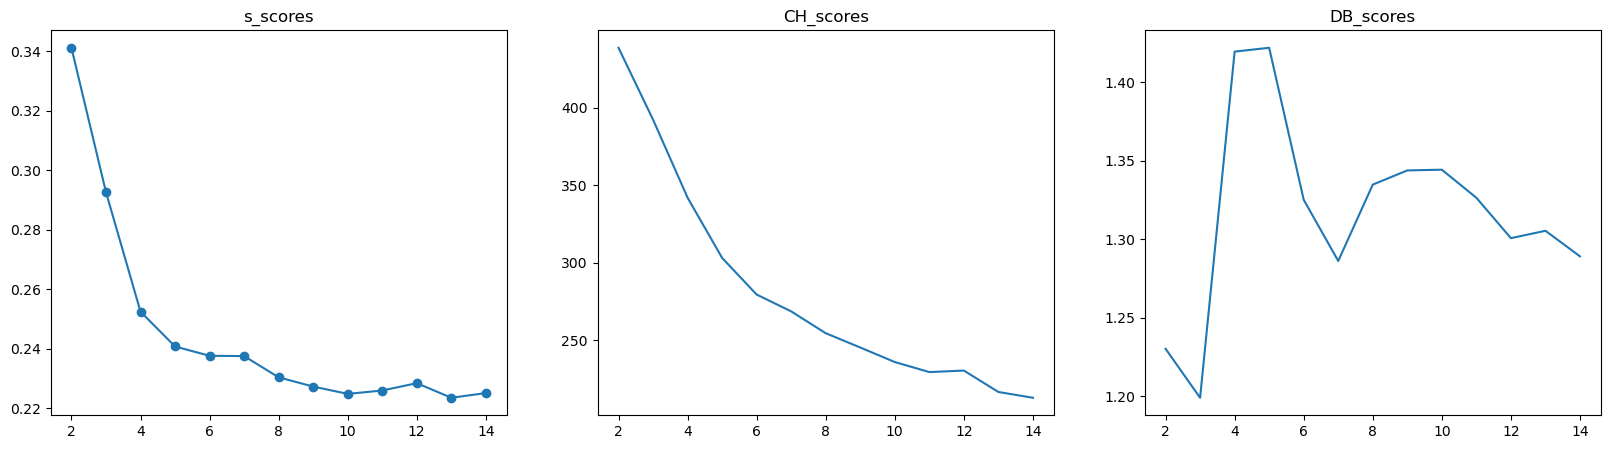

In [10]:
n_seeds = 10

seeds = [12312, 14535, 2345456, 23434, 346667, 7978, 45454, 72673, 6, 2562426] 


s_scores = np.zeros([n_seeds,15]) 
CH_scores =  np.zeros([n_seeds,15])
DB_scores =  np.zeros([n_seeds,15])

for i in range(0,n_seeds):

    seed = seeds[i]

    for k in range(2,15):

        # Test for k-means.
        labels = KMeans(k,random_state=seed).fit_predict(pca_attributes)
        s_scores[i,k] = silhouette_score(pca_attributes,labels) # higher is better
        CH_scores[i,k] = calinski_harabasz_score(pca_attributes,labels) # higher is better
        DB_scores [i,k] = davies_bouldin_score(pca_attributes, labels) # lower is better

avg_s_scores = s_scores.mean(axis=0)[2:]
avg_ch_scores = CH_scores.mean(axis=0)[2:]
avg_db_scores = DB_scores.mean(axis=0)[2:]

fig, axs = plt.subplots(1,3, figsize=(20,5))

axs[0].plot(range(2,15), avg_s_scores, marker="o")
axs[1].plot(range(2,15), avg_ch_scores)
axs[2].plot(range(2,15), avg_db_scores)

axs[0].set_title("s_scores")
axs[1].set_title("CH_scores")
axs[2].set_title("DB_scores")


In [11]:
from sklearn.ensemble import RandomForestClassifier

RF = RandomForestClassifier(random_state=21)

rf_train_id, rf_test_id = train_test_split(kmeans_labels.index, train_size=0.8, random_state=12)

RF.fit(scaled_attributes.loc[rf_train_id,:], kmeans_labels[rf_train_id])

rf_pred = RF.predict(scaled_attributes.loc[rf_test_id,:])

results = kmeans_labels[rf_test_id] == rf_pred

print(f"Accuracy of {results.sum()/len(results)}")

feature_importances = pd.Series(RF.feature_importances_, index=scaled_attributes.columns)

Accuracy of 0.9593023255813954


In [12]:
from scipy.stats import kruskal

# Beispiel: clusters ist eine Series mit Clusterlabels, attributes ein DataFrame mit Variablen
results = {}
for col in scaled_attributes.columns:
    groups = [scaled_attributes.loc[kmeans_labels == c, col].values for c in kmeans_labels.unique()]
    stat, p = kruskal(*groups)
    results[col] = {"H_statistic": stat, "p_value": p}

# Ergebnisse als DataFrame
kruskal_results = pd.DataFrame(results).T
print(kruskal_results)


            H_statistic        p_value
area_calc     15.847170   3.621019e-04
elev_mean    565.906646  1.302966e-123
elev_ran     518.071778  3.177919e-113
slope_mean   562.151827  8.516903e-123
p_mean       569.429480  2.238512e-124
eta_mean     379.458050   3.996975e-83
arid_1       600.304447  4.421256e-131
p_season      10.781744   4.557997e-03
hi_prec_fr   411.100812   5.377655e-90
hi_prec_du    87.948974   7.982205e-20
lo_prec_fr   591.589813  3.450676e-129
lo_prec_du   553.125059  7.769975e-121
frac_snow    627.016185  7.001085e-137
lai_max      251.369250   2.605319e-55
lai_diff     258.140501   8.820689e-57
ndvi_max     266.036765   1.701573e-58
ndvi_min     453.905667   2.726696e-99
gvf_max      202.930612   8.593647e-45
gvf_diff     283.200696   3.189702e-62
bedrk_dep    432.189162   1.416824e-94
soil_poros   246.469464   3.018811e-54
soil_condu   600.750404  3.537589e-131
sand_fra     255.389141   3.491022e-56
silt_fra     284.619847   1.568865e-62
clay_fra     252.363278  

In [13]:
kruskal_results["H_statistic"].sort_values(ascending=False)

frac_snow     627.016185
soil_condu    600.750404
arid_1        600.304447
lo_prec_fr    591.589813
p_mean        569.429480
elev_mean     565.906646
slope_mean    562.151827
lo_prec_du    553.125059
elev_ran      518.071778
ndvi_min      453.905667
bedrk_dep     432.189162
hi_prec_fr    411.100812
eta_mean      379.458050
silt_fra      284.619847
gvf_diff      283.200696
ndvi_max      266.036765
lai_diff      258.140501
sand_fra      255.389141
clay_fra      252.363278
lai_max       251.369250
soil_poros    246.469464
oc_fra        237.927861
gvf_max       202.930612
grav_fra      144.376616
hi_prec_du     87.948974
area_calc      15.847170
p_season       10.781744
Name: H_statistic, dtype: float64

In [14]:
feature_importances.sort_values(ascending=False)

soil_condu    0.137742
lo_prec_fr    0.101535
arid_1        0.094309
frac_snow     0.084832
elev_mean     0.073993
lo_prec_du    0.065002
sand_fra      0.057520
slope_mean    0.055230
p_mean        0.052396
clay_fra      0.035812
soil_poros    0.032884
elev_ran      0.027994
eta_mean      0.027586
silt_fra      0.019719
ndvi_min      0.016780
ndvi_max      0.016183
hi_prec_fr    0.016115
lai_diff      0.016021
lai_max       0.015254
bedrk_dep     0.013407
gvf_max       0.011268
gvf_diff      0.010904
oc_fra        0.005332
p_season      0.004542
hi_prec_du    0.003028
area_calc     0.002412
grav_fra      0.002201
dtype: float64

Ask Bruno, if there exists a priori knowlegde of how many clusters there should be.

Heatmap suffices, no further statistical needed. 

Strong spatial autocorrelation --> convex cluster.

#### Sample a stratified training and validation set. 

In [15]:
seed = 42 

train_ids = []
val_ids = []
test_ids = []

for strata in kmeans_labels.unique(): 

    # Randomly sample 80% of strata for training.
    strata_train_ids, strata_rest_ids = train_test_split(kmeans_labels[kmeans_labels == strata], train_size=0.8)

    # Split the remaining 20% into validation and test. 
    strata_val_ids, strata_test_ids = train_test_split(strata_rest_ids, train_size=0.5)

    train_ids.extend(strata_train_ids.index.to_list())
    val_ids.extend(strata_val_ids.index.to_list())
    test_ids.extend(strata_test_ids.index.to_list())

train_ids.sort()
val_ids.sort()
test_ids.sort()

### Specify the time periods.

##### Visualize normal periods for a subsample of basins. 

Basin 55 is the odd one out, it shows systematic gaps, and is therefore not usable.

In [16]:
discharge_coverage_path = Path("~/BA/data/processed_data/eda/normal_periods.pkl")

discharge_coverage = pd.read_pickle(discharge_coverage_path)

In [17]:
discharge_coverage.loc[1,:]

timeseries_length                                                     8036
start_date                                             1996-01-01 00:00:00
end_date                                               2017-12-31 00:00:00
n_normal_days                                                         7098
q5_q95_normal_periods    [[1996-01-04 00:00:00, 1996-01-05 00:00:00], [...
Name: 1, dtype: object

In [18]:
min_normal_len = 1 

In [19]:
#fig, ax = plt.subplots(figsize=(10, len(discharge_coverage) * 0.25))

yticks = []
yticklabels = []

# Test pickling. 
train_dict = defaultdict(dict)
val_dict = defaultdict(dict)
test_dict = defaultdict(dict)

n_train_samples = 0
n_val_samples = 0
n_test_samples = 0

for basin in discharge_coverage.itertuples():

    basin_id = basin[0]
    n_covered_days = basin[1]
    n_normal_days = basin[1]

    # Perfrom sanity check.
    if n_normal_days == 0: 
        print(f"No normal days in {basin_id}. Coverage of {n_covered_days} days.")
        continue
    
    normal_day_to_day_ratio = n_normal_days / n_covered_days 

    if normal_day_to_day_ratio < 0.85:
        print(f"{basin_id} ratio of {normal_day_to_day_ratio}.")

    # Skip basins, which don't have hydrological IDs. 
    if basin_id not in common_ids: 
        continue

    basin_dict = {
        "start_dates": [basin[2]],
        "end_dates" : [basin[3]]
    }

    
    normal_periods = []

    for period in basin[-1]: 

        x_min = period[0]
        x_width = (period[1] - period[0])

        if x_width.days > min_normal_len: 
            normal_periods.append((x_min,x_width))

            # Attach for pickling. 
            basin_dict["start_dates"].append(period[0])
            basin_dict["end_dates"].append(period[1])

    #ax.broken_barh(xranges=normal_periods, yrange=(len(yticks), 0.5))

    if len(normal_periods) == 0:
        print(basin_id)
        continue

    if basin_id in train_ids: 
        train_dict[str(basin_id)] = basin_dict
        n_train_samples += n_normal_days
    elif basin_id in val_ids:
        val_dict[str(basin_id)] = basin_dict
        n_val_samples += n_normal_days
    else: 
        test_dict[str(basin_id)] = basin_dict
        n_test_samples += n_normal_days

    yticks.append(len(yticks))
    yticklabels.append(basin[0])

#ax.set_yticks(yticks)
#ax.set_yticklabels(yticklabels)
#ax.set_ylim(-1,len(yticks)+1)
#plt.tight_layout()
#plt.show()


In [20]:
test_dict

defaultdict(dict,
            {'3': {'start_dates': [Timestamp('1985-01-01 00:00:00'),
               Timestamp('1985-01-10 00:00:00'),
               Timestamp('1985-01-20 00:00:00'),
               Timestamp('1985-02-07 00:00:00'),
               Timestamp('1985-02-16 00:00:00'),
               Timestamp('1985-08-10 00:00:00'),
               Timestamp('1985-11-19 00:00:00'),
               Timestamp('1986-01-17 00:00:00'),
               Timestamp('1986-02-28 00:00:00'),
               Timestamp('1986-03-19 00:00:00'),
               Timestamp('1986-05-31 00:00:00'),
               Timestamp('1986-10-06 00:00:00'),
               Timestamp('1986-11-02 00:00:00'),
               Timestamp('1987-02-12 00:00:00'),
               Timestamp('1987-02-28 00:00:00'),
               Timestamp('1987-03-25 00:00:00'),
               Timestamp('1987-06-18 00:00:00'),
               Timestamp('1987-08-08 00:00:00'),
               Timestamp('1987-08-26 00:00:00'),
               Timestamp('1988-

In [21]:
n_test_samples

1069318

#### Export time periods as .pkl and basin id splits as .txt.

In [22]:
import pickle as pkl

splits_directory_path = Path("/home/wuhlmann/BA/data/processed_data/test_splits")

with open(splits_directory_path / "train.pkl", "wb") as out: 
    pkl.dump(train_dict, out, protocol=pkl.HIGHEST_PROTOCOL)

with open(splits_directory_path / "val.pkl", "wb") as out: 
    pkl.dump(val_dict, out, protocol=pkl.HIGHEST_PROTOCOL)

with open(splits_directory_path / "test.pkl", "wb") as out: 
    pkl.dump(test_dict, out, protocol=pkl.HIGHEST_PROTOCOL)


In [23]:
with open(splits_directory_path / "train_basin_ids.txt", "w") as f: 
    for id in train_dict.keys():
        f.write(f"{id}\n")

with open(splits_directory_path / "val_basin_ids.txt", "w") as f: 
    for id in val_dict.keys():
        f.write(f"{id}\n")

with open(splits_directory_path / "test_basin_ids.txt", "w") as f: 
    for id in test_dict.keys():
        f.write(f"{id}\n")

In [24]:
kmeans_labels

ID
1      0
2      0
3      0
4      2
5      2
      ..
878    1
879    1
880    1
881    1
882    1
Length: 858, dtype: int32

In [25]:
#export Strata
kmeans_labels.to_csv(splits_directory_path / "strata_ids.txt")